In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

In [3]:
EVAL_RESULTS_DIR = Path("evaluation_results")

# Task configuration: task_key -> (primary_dataset, secondary_dataset, metric_key, scale_factor)
# primary = intra_dataset, secondary = intra_task
TASK_CONFIG = {
    'NLU': {
        'primary': 'ArabicMMLU',
        'secondary': 'belebele',
        'prompt_ids': {
            'primary': [14571, 14869, 14787, 14797, 14798],
            'secondary': [14854, 14853, 14801, 14800, 14575],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'NLI': {
        'primary': 'ArEntail',
        'secondary': 'ArabicTE',
        'prompt_ids': {
            'primary': [14581, 14816, 14818, 14819, 14820],
            'secondary': [14582, 14673, 14724, 14805, 14855],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Dialect': {
        'primary': 'AraBench_dev',
        'secondary': 'Arabic_Dialects_Dataset',
        'prompt_ids': {
            'primary': [14852, 14850, 14789, 14781, 14561],
            'secondary': [14102, 14783, 14784, 14790, 14851],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Sarcasm': {
        'primary': 'ArSarcasm_v2',
        'secondary': 'iSarcasmEval_task_A',
        'prompt_ids': {
            'primary': [14779, 14802, 14835, 14837, 14838],
            'secondary': [14602, 14780, 14859, 14860, 14864],
        },
        'metric': 'acc_norm,none',
        'scale': 100,
    },
    'Translation': {
        'primary': 'opus-100',
        'secondary': 'tatoeba_mt',
        'prompt_ids': {
            'primary': [14684, 14688, 14680, 14682, 14640],
            'secondary': [14866, 14867, 14868, 14889, 14890],
        },
        'metric': 'calculate_bleu,none',
        'scale': 1,
    },
    'Summarization': {
        'primary': 'xlsum',
        'secondary': 'AraSum',
        'prompt_ids': {
            'primary': [14871, 14803, 14856, 14858, 14668],
            'secondary': [14891, 14857, 14736, 14735, 14628],
        },
        'metric': 'calculate_bleu,none',
        'scale': 1,
    },
}

# Task name -> eval directory name
TASK_DIR_MAP = {
    'NLU': 'NLU',
    'NLI': 'NLI',
    'Dialect': 'dialect_identification',
    'Sarcasm': 'sarcasm_detection',
    'Translation': 'machine_translation',
    'Summarization': 'summarization',
}

# Model configuration: display_name -> {variant_label: results_dir_name}
MODEL_CONFIG = {
    'AceGPT-v2-8B': {
        'Base': 'AceGPT-v2-8B',
        'Chat': 'AceGPT-v2-8B-Chat',
        'Tuned': 'AceGPT-v2-8B-tuned',
    },
    'LLaMA3.1-8B': {
        'Base': 'Meta-Llama-3.1-8B',
        'Instruct': 'Meta-Llama-3.1-8B-Instruct',
        'Tuned': 'Meta-Llama-3.1-8B-tuned',
    },
    'Qwen3-8B': {
        'Base': 'Qwen3-8B',
        'Chat': 'Qwen3-8B-chat',
        'Tuned': 'Qwen3-8B-tuned',
    },
}


def get_prompt_ids(task_config, dataset_type):
    """Get prompt IDs for a dataset type (primary/secondary)."""
    pids = task_config['prompt_ids']
    if isinstance(pids, dict):
        return pids[dataset_type]
    return pids


def extract_metric(result_json, metric_key):
    """Extract metric value from lm-eval result JSON."""
    results = result_json.get('results', {})
    for task_name, metrics in results.items():
        if metric_key in metrics:
            val = metrics[metric_key]
            if isinstance(val, (int, float)):
                return val
    return None


def load_results():
    """Dynamically load all results from evaluation_results/."""
    data = {}
    
    # Count total iterations for progress bar
    total = len(TASK_CONFIG) * len(MODEL_CONFIG) * 2 * 3  # tasks × models × conditions × variants
    pbar = tqdm(total=total, desc="Loading results")
    
    for task_name, task_cfg in TASK_CONFIG.items():
        task_dir = TASK_DIR_MAP[task_name]
        metric_key = task_cfg['metric']
        scale = task_cfg['scale']
        
        data[task_name] = {'intra_dataset': {}, 'intra_task': {}}
        
        for model_display, variants in MODEL_CONFIG.items():
            for condition, dataset_type in [('intra_dataset', 'primary'), ('intra_task', 'secondary')]:
                prompt_ids = get_prompt_ids(task_cfg, dataset_type)
                dataset_name = task_cfg[dataset_type]
                
                for variant_label, model_dir in variants.items():
                    pbar.set_postfix_str(f"{task_name}/{model_dir}/{variant_label}")
                    scores = []
                    for pid in prompt_ids:
                        fpath = EVAL_RESULTS_DIR / model_dir / task_dir / dataset_name / f"prompt_{pid}.json"
                        if fpath.exists():
                            with open(fpath) as f:
                                result = json.load(f)
                            val = extract_metric(result, metric_key)
                            if val is not None:
                                scores.append(val * scale)
                            else:
                                print(f"WARNING: metric '{metric_key}' not found in {fpath}")
                        else:
                            print(f"WARNING: missing {fpath}")
                    
                    if model_display not in data[task_name][condition]:
                        data[task_name][condition][model_display] = {}
                    data[task_name][condition][model_display][variant_label] = scores
                    pbar.update(1)
    
    pbar.close()
    return data


data = load_results()

# Print summary
for task, conditions in data.items():
    for cond, models in conditions.items():
        for model, variants in models.items():
            for var, scores in variants.items():
                print(f"{task:>15} | {cond:>14} | {model:>14} | {var:>10} | mean={np.mean(scores):6.2f} | n={len(scores)}")

Loading results:   0%|          | 0/108 [00:00<?, ?it/s]

            NLU |  intra_dataset |   AceGPT-v2-8B |       Base | mean= 42.35 | n=5
            NLU |  intra_dataset |   AceGPT-v2-8B |       Chat | mean= 46.01 | n=5
            NLU |  intra_dataset |   AceGPT-v2-8B |      Tuned | mean= 59.45 | n=5
            NLU |  intra_dataset |    LLaMA3.1-8B |       Base | mean= 39.95 | n=5
            NLU |  intra_dataset |    LLaMA3.1-8B |   Instruct | mean= 44.03 | n=5
            NLU |  intra_dataset |    LLaMA3.1-8B |      Tuned | mean= 55.37 | n=5
            NLU |  intra_dataset |       Qwen3-8B |       Base | mean= 51.30 | n=5
            NLU |  intra_dataset |       Qwen3-8B |       Chat | mean= 49.47 | n=5
            NLU |  intra_dataset |       Qwen3-8B |      Tuned | mean= 66.04 | n=5
            NLU |     intra_task |   AceGPT-v2-8B |       Base | mean= 42.02 | n=5
            NLU |     intra_task |   AceGPT-v2-8B |       Chat | mean= 57.00 | n=5
            NLU |     intra_task |   AceGPT-v2-8B |      Tuned | mean= 58.13 | n=5
    

In [6]:
def create_stacked_bar_charts(figsize=(24, 8)):
    """Create unified stacked bar chart with incremental differences from lowest to highest."""
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Colors based on brand/logo colors (light=Base, medium=Chat/Instruct, dark=Tuned)
    colors = {
        'AceGPT-v2-8B':  ['#7ECDC6', '#2BA89E', '#1A6B64'],  # Teal/cyan (KAUST branding)
        'LLaMA3.1-8B':   ['#6FA8F2', '#0668E1', '#044A9E'],  # Meta blue
        'Qwen3-8B':      ['#B794F6', '#7C3AED', '#5521A6'],  # Purple/violet (Qwen branding)
    }
    
    patterns = {
        'intra_dataset': '',     # Solid fill
        'intra_task': '///'      # Diagonal hatching
    }
    
    tasks = list(data.keys())
    models = list(MODEL_CONFIG.keys())
    conditions = ['intra_dataset', 'intra_task']
    bars_per_task = len(models) * len(conditions)  # 3 models × 2 conditions = 6
    
    bar_width = 0.55
    gap_between_tasks = 1.5  # extra gap between task groups
    
    # Build x positions with gaps between task groups
    x_positions = []
    x_labels_tasks = []
    pos = 0
    for task_idx, task in enumerate(tasks):
        task_start = pos
        for model_idx, model in enumerate(models):
            for cond_idx, condition in enumerate(conditions):
                x_positions.append(pos)
                pos += 1
        task_end = pos - 1
        task_display = task.replace('NLU', 'MCQ')
        x_labels_tasks.append(((task_start + task_end) / 2, task_display))
        pos += gap_between_tasks  # gap before next task
    
    # Plot each bar
    for bar_i, x_pos in enumerate(x_positions):
        # Figure out which task/model/condition from the flat index
        cumulative = 0
        task_idx = model_idx = cond_idx = 0
        remaining = bar_i
        for ti in range(len(tasks)):
            count = bars_per_task
            if remaining < count:
                task_idx = ti
                model_idx = remaining // len(conditions)
                cond_idx = remaining % len(conditions)
                break
            remaining -= count
        
        task = tasks[task_idx]
        model = models[model_idx]
        condition = conditions[cond_idx]
        
        # Get scores for each variant
        performance_data = {}
        for variant_key, values in data[task][condition][model].items():
            if len(values) > 0:
                performance_data[variant_key] = np.mean(values)
        
        if not performance_data:
            continue
        
        # Sort by performance (lowest first for stacking)
        sorted_variants = sorted(performance_data, key=lambda x: performance_data[x])
        highest_performance = max(performance_data.values())
        
        # Stack bars
        bottom = 0
        for stack_idx, variant in enumerate(sorted_variants):
            current_perf = performance_data[variant]
            if stack_idx == 0:
                height = current_perf
            else:
                prev_perf = performance_data[sorted_variants[stack_idx - 1]]
                height = current_perf - prev_perf
            
            # Map variant to color index
            if variant == 'Base':
                color_idx = 0
            elif variant in ('Chat', 'Instruct'):
                color_idx = 1
            else:  # Tuned
                color_idx = 2
            
            ax.bar(x_pos, height, bar_width, bottom=bottom,
                   color=colors[model][color_idx], alpha=0.85,
                   edgecolor='white', linewidth=0.8,
                   hatch=patterns[condition])
            bottom += height
        
        # Label on top of each bar
        ax.text(x_pos, bottom + highest_performance * 0.01, f'{highest_performance:.1f}',
                ha='center', va='bottom', fontsize=15, fontweight='bold', color='#333333')
    
    # Axes styling
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel('Performance', fontsize=22, fontweight='bold')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#666666')
    
    # Task labels below x-axis
    for task_center, task_name in x_labels_tasks:
        ax.text(task_center, -ax.get_ylim()[1] * 0.03, task_name,
                ha='center', va='top', fontsize=20, fontweight='bold', color='#333333')
    
    # Separators between tasks
    for i in range(1, len(tasks)):
        prev_task_end = x_positions[i * bars_per_task - 1]
        curr_task_start = x_positions[i * bars_per_task]
        sep_x = (prev_task_end + curr_task_start) / 2
        ax.axvline(x=sep_x, color='#CCCCCC', linewidth=1.5, alpha=0.8)
    
    # Major divider between classification (first 4) and generation (last 2) tasks
    prev_end = x_positions[4 * bars_per_task - 1]
    curr_start = x_positions[4 * bars_per_task]
    major_sep = (prev_end + curr_start) / 2
    ax.axvline(x=major_sep, color="#000F02", linewidth=4, alpha=0.8)
    
    # Category labels at top
    ylim_top = ax.get_ylim()[1]
    
    left_center = (x_positions[0] + x_positions[4 * bars_per_task - 1]) / 2
    ax.text(left_center, ylim_top * 1.05, 'Answer Choices Tasks',
            ha='center', va='bottom', fontsize=20, fontweight='bold', color='#333333',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFFFF", alpha=0.7))
    
    right_center = (x_positions[4 * bars_per_task] + x_positions[-1]) / 2
    ax.text(right_center, ylim_top * 1.05, 'Open-Ended Generation Tasks',
            ha='center', va='bottom', fontsize=20, fontweight='bold', color='#333333',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFFFF", alpha=0.7))
    
    # Subtle separators between model groups within each task
    for task_idx in range(len(tasks)):
        for model_idx in range(1, len(models)):
            idx = task_idx * bars_per_task + model_idx * len(conditions) - 1
            next_idx = idx + 1
            if next_idx < len(x_positions):
                sep_x = (x_positions[idx] + x_positions[next_idx]) / 2
                ax.axvline(x=sep_x, color='#E8E8E8', linewidth=1, alpha=0.6)
    
    # Legend
    legend_elements = []
    model_labels = {'AceGPT-v2-8B': 'AceGPT-v2', 'LLaMA3.1-8B': 'LLaMA-3.1', 'Qwen3-8B': 'Qwen3'}
    for model in models:
        for vi, vname in enumerate(['Base', 'Chat/Instruct', 'Tuned']):
            legend_elements.append(plt.Rectangle(
                (0, 0), 1, 1, facecolor=colors[model][vi],
                edgecolor='white', linewidth=0.8, alpha=0.85,
                label=f'{model_labels[model]} {vname}'))
    
    legend_elements.append(plt.Rectangle(
        (0, 0), 1, 1, facecolor='#888888', alpha=0.6,
        edgecolor='white', linewidth=0.8, label='Intra-Dataset'))
    legend_elements.append(plt.Rectangle(
        (0, 0), 1, 1, facecolor='#888888', alpha=0.6,
        hatch='///', edgecolor='white', linewidth=0.8, label='Intra-Task'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.08),
              ncol=4, fontsize=18, frameon=True, fancybox=True, shadow=False,
              edgecolor='#CCCCCC', facecolor='#FAFAFA', columnspacing=2.0)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.22)
    
    return fig

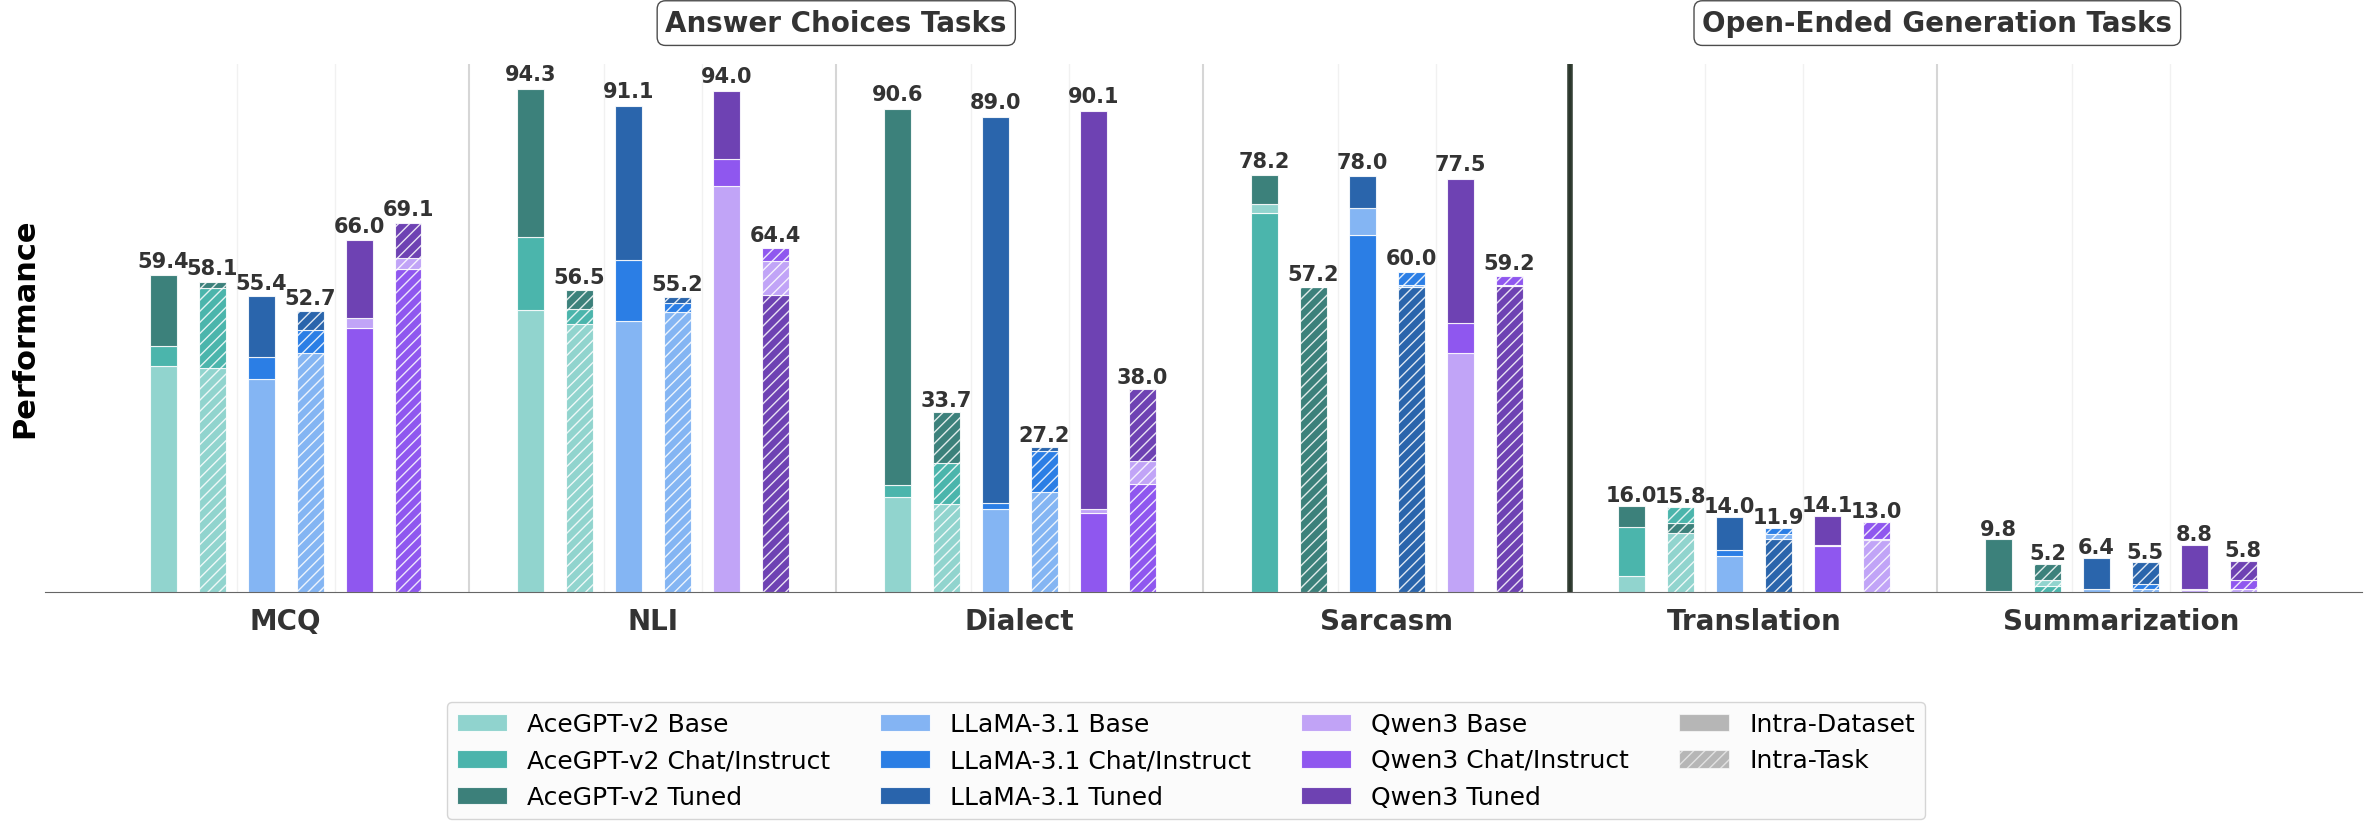

In [7]:
plot = create_stacked_bar_charts()
plt.savefig('Notebooks/results_visualization/stacked_bar_chart.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()